In [2]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

In this notebook, we will use `pytorch` to implement a MLP.

Let us start with some data (moon example).

In [3]:
X, y = make_moons(n_samples=1000, noise=0.2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Pytorch operates on `tensor` objects, so we should convert our data to this data type:

In [4]:
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long).flatten()
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.long).flatten()

Moreover, we can collect our datasets (for training and testing) in `TensorDatasets`, which can be passedd to `DataLoaders`.
`DataLoaders` are convenient objects that store and pass data during training.

In [5]:
train_ds = TensorDataset(X_train, y_train)
test_ds = TensorDataset(X_test, y_test)
train_dl = DataLoader(train_ds, batch_size=32, shuffle=True)
test_dl = DataLoader(test_ds, batch_size=32)

Next, we can create our network as a sequence of layers. 
Using `nn.Sequential` can be convenient to group individual layers, in this example `Linear` and `ReLU` layers.

We also must define a `forward` method, that describe the operation performed by the model. In this case, evaluation of the sequence of layers

In [6]:
class SimpleMLP(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, output_size)
        )

    def forward(self, x):
        return self.layers(x)

The model can be instantiated as you would expect:

In [7]:
model = SimpleMLP(input_size=2, hidden_size=32, output_size=2)
model

SimpleMLP(
  (layers): Sequential(
    (0): Linear(in_features=2, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=2, bias=True)
  )
)

We will also need a loss function (in this case: `CrossEntropyLoss`, see the documentation for more options) and an optimizer (we will use `Adam`).

It is necessary to "tell" the optimizer what should be optimized (the parameters of the model), as well as optimizer specific parameters such as the learning rate.

In [8]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

Next, we can loop several times over the dataset (a full pass is called an `epoch`) and:

- evaluate the model
- calculate the loss
- reset the gradient
- calculate the gradient
- perform one optimization step

In [9]:
for epoch in range(50):
    for xb, yb in train_dl:
        pred = model(xb)
        loss = loss_fn(pred, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

To evaluate the model, we need to set the model to evaluation mode (`model.eval()`) to make sure that no state is changed.

In [10]:
model.eval()
correct = 0
with torch.no_grad():
    for xb, yb in test_dl:
        pred = model(xb)
        correct += (pred.argmax(dim=1) == yb).sum().item()


accuracy = correct / len(test_ds)
print(f"Test accuracy: {accuracy:.3f}")

Test accuracy: 0.945


Visualize the decision function

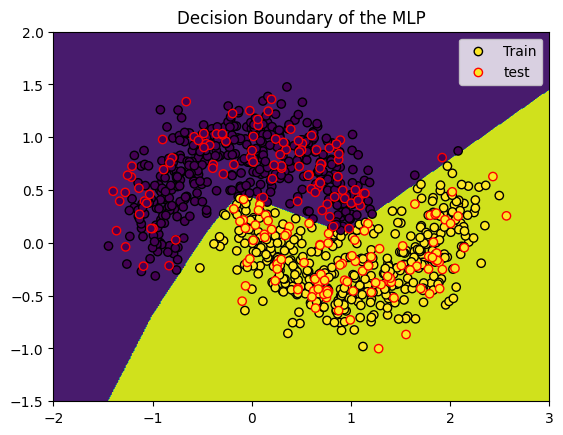

In [11]:
import numpy as np
xx, yy = np.meshgrid(np.linspace(-2, 3, 400), np.linspace(-1.5, 2, 400))
grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)


with torch.no_grad():
    Z = model(grid).argmax(dim=1).reshape(xx.shape)


preds_train = np.argmax(model(X_train).detach().numpy(),1)
preds_test = np.argmax(model(X_test).detach().numpy(),1)

plt.contourf(xx, yy, Z)
plt.scatter(X_train[:, 0], X_train[:, 1], c=preds_train, edgecolors='k', label="Train")
plt.scatter(X_test[:, 0], X_test[:, 1], c=preds_test, edgecolors='r', label="test")
plt.title("Decision Boundary of the MLP")
plt.legend()
plt.show()